# WS-01 — Débruitage d'images : du seuillage *from scratch* aux estimateurs SOTA

Bloc B.5 de la série ([#16055](https://github.com/jsboige/CoursIA/issues/16055)). Suite directe de
[`WS-00a-Ondelettes-1D-from-scratch`](WS-00a-Ondelettes-1D-from-scratch.ipynb) (seuil MAD, seuillage dur/doux)
et de [`WS-00b-Ondelettes-2D-from-scratch`](WS-00b-Ondelettes-2D-from-scratch.ipynb) (moteur 2D séparable).

Le cap de la série s'inverse ici, délibérément. Dans les WS-00, `pywt` n'intervenait **jamais pour calculer** —
seulement comme référence de validation croisée. Ce notebook est le pendant **SOTA** du bloc B : les bibliothèques
(`pywt`, `scikit-image`) **calculent désormais**, et le moteur from scratch des WS-00 devient la **baseline**
que l'on affronte sur le même banc.

**Ce que ce notebook établit :**

1. À transformée identique (db4, 4 niveaux, péridiodisation — vérifiée par parité `allclose`), **tout l'écart de
   débruitage vient de l'estimation du seuil**, pas de la transformée. Le SOTA à l'œuvre ici est un *estimateur*,
   pas un moteur.
2. **BayesShrink** (seuil adaptatif par sous-bande, Chang-Yu-Vetterli) domine nettement le seuil universel global
   de WS-00a : **+2,2 à +3,0 dB** sur le banc complet (moyenne 4 images, à chaque régime de bruit).
3. **SureShrink** n'est pas dans scikit-image : on l'implémente à la main (minimisation du risque SURE de
   Donoho-Johnstone) sur les coefficients que `pywt` fournit — la frontière exacte entre *ce que la lib sait faire*
   et *ce qui relève de l'estimation*.


In [1]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from skimage.data import camera, moon, coins, text
from skimage.restoration import denoise_wavelet
from skimage.metrics import structural_similarity

SQ2 = np.sqrt(2.0)
HAAR = np.array([1.0, 1.0]) / SQ2
DB4 = np.array([
    -0.010597401785069032, 0.0328830116668852, 0.030841381835560764,
    -0.18703481171909309, -0.027983769416859854, 0.6308807679298589,
    0.7148465705529157, 0.2303778133088965,
])  # constantes publiques db4 -- celles de WS-00a/WS-00b

ONDELETTE_LIB = "db4"   # meme famille que le moteur from scratch (appariee)
NIVEAUX = 4

print("numpy", np.__version__, "| pywt", pywt.__version__,
      "| matplotlib", plt.matplotlib.__version__)
import skimage
print("scikit-image", skimage.__version__, "-- bloc B : les libs CALCULENT desormais")

numpy 2.2.6 | pywt 1.8.0 | matplotlib 3.10.8
scikit-image 0.26.0 -- bloc B : les libs CALCULENT desormais


## 1. Le banc d'essai

Quatre images canoniques de `skimage.data` (aucun chemin local : le banc est reproductible partout), recadrées
en multiples de $2^4$ pour que la pyramide à 4 niveaux soit exacte. Bruit blanc gaussien additif à trois régimes
($\sigma \in \{10, 20, 30\}$ sur l'échelle 0–255), trois graines par configuration — les moyennes portent
donc sur 4 images × 3 sigmas × 3 graines.

Deux métriques : le **PSNR** (définition maison de WS-00b, pour la continuité de la série) et le **SSIM**
(`skimage.metrics`, l'indice structural de référence — montré sur les vignettes du duel visuel).
PSNR et SSIM ne jugent pas la même chose : le premier somme une énergie
d'erreur (un décalage global de contraste le paie autant qu'un grain fin), le
second compare des structures locales (il pardonne le contraste, punit la
texture effacée). Les deux sont rapportés — PSNR au banc, SSIM au duel — parce
qu'un débruiteur peut gagner en décibels ce qu'il perd en structure, et
vice-versa.

  camera   (512, 512)  [0, 255]
  moon     (512, 512)  [0, 255]
  coins    (288, 384)  [1, 252]
  text     (160, 448)  [10, 197]


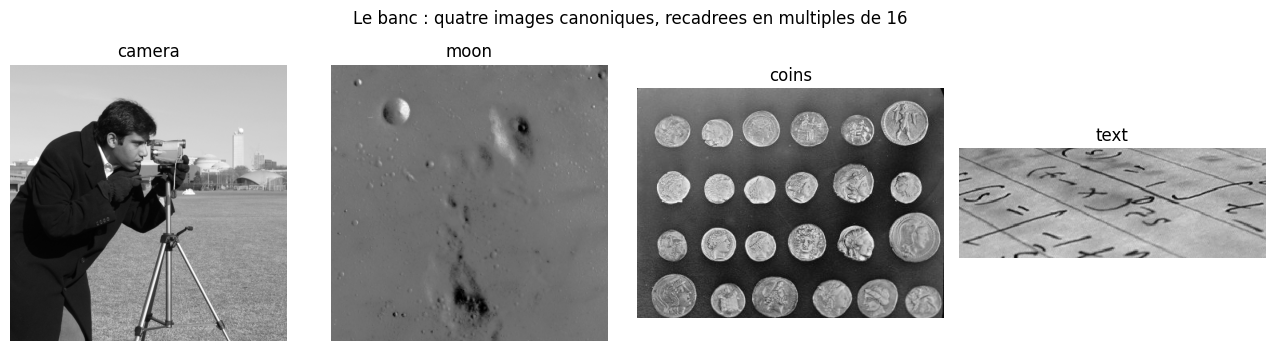

In [2]:
def psnr(ref, test, peak=255.0):
    """PSNR en dB (peak = 255 : images 8 bits) -- definition WS-00b."""
    mse = np.mean((ref - test) ** 2)
    return 10 * np.log10(peak ** 2 / mse) if mse > 0 else float("inf")


IMAGES = {"camera": camera(), "moon": moon(), "coins": coins(), "text": text()}
M = 2 ** NIVEAUX
IMAGES = {k: np.asarray(v, dtype=float)[: (v.shape[0] // M) * M, : (v.shape[1] // M) * M]
          for k, v in IMAGES.items()}
for k, v in IMAGES.items():
    print(f"  {k:8s} {v.shape}  [{v.min():.0f}, {v.max():.0f}]")

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (k, v) in zip(axes, IMAGES.items()):
    ax.imshow(v, cmap="gray")
    ax.set_title(k)
    ax.axis("off")
fig.suptitle("Le banc : quatre images canoniques, recadrees en multiples de 16", y=1.02)
plt.tight_layout()
plt.show()

**Lecture.** Le banc couvre quatre régimes visuels distincts, et ce n'est pas un
luxe de variété. `camera` et `moon` tiennent le carré complet (512 × 512,
dynamique pleine 0–255) ; `coins` est plus petit (288 × 384) et contraste des
objets lisses sur un fond régulier ; `text` surtout (160 × 448, dynamique
réduite [10, 197]) vit entièrement de **contours fins** — ses lettres. Ces
profils anticipent la suite : une image lisse comme `moon` concentrera
l'énergie sur peu de coefficients (le seuillage y sera presque gratuit), une
image texturée comme `camera` en semera partout (le choix du seuil y sera
déterminant), et `text` posera à l'exercice 3 la question du biais de
$\hat\sigma$ — quand les contours fuient dans la bande que l'on croit pure
bruit. Le recadrage en multiples de $2^4$ n'est pas cosmétique : la pyramide
à 4 niveaux exige des dimensions divisibles par 16 pour que la périodisation
de chaque étage tombe juste.

## 2. La baseline *from scratch* — le moteur de WS-00b, rapatrié

Le moteur 2D est celui de WS-00b (les mêmes fonctions, la même convention PyWavelets pour le miroir quadratique) :
analyse séparable le long des lignes puis des colonnes, synthèse écrite comme **adjoint exact**. Rien de nouveau
ici — c'est précisément le point : la baseline hérite du socle de la série, vérifiée à nouveau par deux contrôles
(adjoint exact, parité `allclose` bande par bande contre `pywt.dwt2`).

Le seuillage est l'héritage direct de WS-00a : $\hat\sigma$ par MAD sur la bande diagonale la plus fine,
seuil **universel** $\lambda = \hat\sigma\sqrt{2\ln N}$ **global** à toutes les bandes de détail,
l'approximation toujours gardée. Dur et doux.


In [3]:
def qmf(lo):
    """Passe-haut d'analyse, convention PyWavelets : g_j = (-1)^(j+1) * h_{n-1-j}."""
    return ((-1.0) ** (np.arange(len(lo)) + 1)) * lo[::-1]


def dwt_axis(x, lo):
    """Un niveau de DWT le long du DERNIER axe, periodization (formule WS-00a/WS-00b)."""
    N, n = x.shape[-1], len(lo)
    hi = qmf(lo)
    a = np.zeros(x.shape[:-1] + (N // 2,))
    d = np.zeros_like(a)
    k = np.arange(N // 2)
    for j in range(n):
        xj = np.take(x, (2 * k + n // 2 - j) % N, axis=-1)
        a += lo[j] * xj
        d += hi[j] * xj
    return a, d


def idwt_axis(a, d, lo):
    """Synthese = adjoint exact de dwt_axis (meme expression d'indice, on accumule)."""
    N, n = 2 * a.shape[-1], len(lo)
    hi = qmf(lo)
    x = np.zeros(a.shape[:-1] + (N,))
    k = np.arange(a.shape[-1])
    for j in range(n):
        pos = (2 * k + n // 2 - j) % N
        x[..., pos] += a * lo[j] + d * hi[j]
    return x


def dwt2(img, lo):
    """Analyse 2D separable -> (approximation, (cH, cV, cD)), appariement WS-00b."""
    lr, hr = dwt_axis(img, lo)
    ll, lh = dwt_axis(lr.T, lo)
    hl, hh = dwt_axis(hr.T, lo)
    return ll.T, (lh.T, hl.T, hh.T)


def idwt2(app, det, lo):
    """Synthese : adjoint exact, appariement STRICTEMENT celui de dwt2 (piege WS-00b)."""
    cH, cV, cD = det
    lr = idwt_axis(app.T, cH.T, lo).T
    hr = idwt_axis(cV.T, cD.T, lo).T
    return idwt_axis(lr, hr, lo)


def wavedec2(img, lo, level):
    """Pyramide : [approx_L, (cH_L,cV_L,cD_L), ..., (cH_1,cV_1,cD_1)]."""
    coeffs, a = [], img.astype(float)
    for _ in range(level):
        a, det = dwt2(a, lo)
        coeffs.append(det)
    return [a] + coeffs[::-1]


def waverec2(coeffs, lo):
    a = coeffs[0].copy()
    for det in coeffs[1:]:
        a = idwt2(a, det, lo)
    return a


# --- controle 1 : adjoint exact (reconstruction parfaite) ---
img0 = next(iter(IMAGES.values()))
co = wavedec2(img0, DB4, NIVEAUX)
err = np.max(np.abs(waverec2(co, DB4) - img0))
print(f"controle adjoint : erreur max de reconstruction = {err:.2e}")

# --- controle 2 : parite bande par bande contre pywt (niveau 1) ---
app, (cH, cV, cD) = dwt2(img0, DB4)
r_app, (r_H, r_V, r_D) = pywt.dwt2(img0, ONDELETTE_LIB, mode="periodization")
print(f"parite vs pywt.dwt2 : app {np.max(np.abs(app - r_app)):.2e} | "
      f"cH {np.max(np.abs(cH - r_H)):.2e} | cV {np.max(np.abs(cV - r_V)):.2e} | "
      f"cD {np.max(np.abs(cD - r_D)):.2e}")

controle adjoint : erreur max de reconstruction = 3.98e-13
parite vs pywt.dwt2 : app 2.27e-13 | cH 1.26e-13 | cV 1.42e-13 | cD 4.77e-14


**Lecture.** Les deux contrôles tombent à l'échelle de la machine :
3,98 × 10⁻¹³ pour la reconstruction par l'adjoint, et des parités bande par
bande contre `pywt.dwt2` entre 4,77 × 10⁻¹⁴ et 2,27 × 10⁻¹³ — deux à trois
ordres de grandeur au-dessus de l'epsilon du flottant double : la marge d'un
calcul réarrangé (les mêmes sommes dans un autre ordre), pas d'une erreur
d'algorithme. Le premier contrôle certifie que `idwt_axis` est
**exactement** l'adjoint de `dwt_axis` — l'identité est algébrique (même
expression d'indices, on accumule au lieu de prélever), seul l'arrondi
flottant s'invite. Le second certifie l'**équivalence d'analyse** avec la
bibliothèque : même convention de miroir quadratique, même alignement de
phase. C'est ce double acquis qui rend honnêtes les claims du banc : quand
la section 4 dira « transformée identique partout, seul le seuil change »,
ce n'est pas une approximation — c'est mesuré bande par bande ici.

In [4]:
def sigma_hat_mad(img):
    """sigma du bruit par MAD sur la bande diagonale la plus fine (heritage WS-00a)."""
    coeffs = wavedec2(img, DB4, NIVEAUX)
    hh = coeffs[-1][2]
    return np.median(np.abs(hh - np.median(hh))) / 0.6745


def shrink2(coeffs, threshold, soft):
    """Seuillage des bandes de detail (approximation toujours gardee) -- WS-00a en 2D."""
    out = [coeffs[0]]
    for det in coeffs[1:]:
        out.append(tuple(
            np.sign(b) * np.maximum(np.abs(b) - threshold, 0.0) if soft
            else np.where(np.abs(b) > threshold, b, 0.0)
            for b in det))
    return out


def denoise_scratch(img, soft):
    """Baseline from scratch : moteur WS-00b + seuil universel global de WS-00a."""
    coeffs = wavedec2(img, DB4, NIVEAUX)
    lam = sigma_hat_mad(img) * np.sqrt(2.0 * np.log(img.size))
    shrinked = shrink2(coeffs, lam, soft)
    kept = sum(int(np.count_nonzero(b)) for det in shrinked[1:] for b in det)
    total = sum(b.size for det in coeffs[1:] for b in det)
    return np.clip(waverec2(shrinked, DB4), 0, 255), kept, total

## 3. Les estimateurs SOTA — trois façons de choisir le seuil

La transformée est réglée une fois pour toutes (db4, 4 niveaux, periodization — les mêmes réglages des deux
côtés, from scratch et lib). Reste la seule vraie question du débruitage par ondelettes : **quel seuil, sur
quelles bandes ?**

| Estimateur | Origine | Seuil | Portée |
|---|---|---|---|
| **VisuShrink** | Donoho-Johnstone, packaging scikit-image | $\lambda = \hat\sigma\sqrt{2\ln N}$ | global |
| **BayesShrink** | Chang-Yu-Vetterli 2000, scikit-image | $\lambda_B = \hat\sigma^2/\hat\sigma_x$ | **par sous-bande** |
| **SureShrink** | Donoho-Johnstone, **implémenté ici** | $\lambda^* = \arg\min_t \mathrm{SURE}(t)$ | par sous-bande |

BayesShrink adapte le seuil à chaque sous-bande : $\hat\sigma_x^2$ est la variance *empirique* des coefficients
de la bande, donc $\lambda_B$ grandit quand la bande est pauvre en signal (fort seuil) et rétrécit quand elle
en est riche (seuil prudent). C'est l'inverse du seuil universel, identique partout et calibré pour le pire cas.

SureShrink minimise le risque **SURE** (*Stein's Unbiased Risk Estimate*) — une estimation sans oracle du risque
quadratique, évaluable pour chaque seuil candidat sur les seuls coefficients observés. scikit-image ne le fournit
pas : la cellule ci-dessous l'écrit en $O(n \log n)$ par tri (formule vectorisée), et le **valide contre une
recherche par force brute** sur un signal synthétique — la série exige la parité mesurée, y compris pour le code
écrit ici.

**Équité** : les trois estimateurs reçoivent le même $\hat\sigma$ (MAD, cellule §2) via `sigma=`, `rescale_sigma=False`.


In [5]:
def sure_lambda(band, sigma):
    """Seuil SURE par minimisation du risque de Stein, en O(n log n) par tri.

    SURE(t) = n + somme_i min(|d_i|, t)^2 - 2 * #{ |d_i| <= t }   (unites : d/sigma)

    Pour t = xs[k] (les |d| tries par ordre decroissant) :
      somme min(|d_i|, t)^2 = (k+1) * t^2 + (total - somme des k+1 plus grands carres)
      #{ |d_i| <= t }       = n - k
    Le candidat retenu est celui qui minimise SURE parmi les n valeurs observees.
    """
    xs = np.sort(np.abs(band).ravel() / sigma)[::-1]
    n = xs.size
    sq = np.cumsum(xs ** 2)
    k = np.arange(n)
    smin = (k + 1) * xs ** 2 + (sq[-1] - sq)
    sure = n + smin - 2 * (n - k)
    return xs[int(np.argmin(sure))] * sigma


# --- validation contre une recherche par force brute (signal spikes + bruit) ---
rng_val = np.random.default_rng(7)
x_val = rng_val.standard_normal(512)
x_val[np.arange(0, 500, 100)] += np.array([6.0, -5.0, 8.0, 4.0, -7.0])
grille = np.linspace(0.0, np.abs(x_val).max(), 400)
risques = [x_val.size + np.sum(np.minimum(np.abs(x_val), t) ** 2)
           - 2 * np.count_nonzero(np.abs(x_val) <= t) for t in grille]
lam_brute = grille[int(np.argmin(risques))]
lam_trie = sure_lambda(x_val, 1.0)
print(f"validation SURE : force brute {lam_brute:.3f} vs tri vectorise {lam_trie:.3f} "
      f"(ecart {abs(lam_brute - lam_trie):.1e})")


def denoise_visu(img, sigma):
    """VisuShrink via scikit-image : seuil universel, packaging lib, doux."""
    out = denoise_wavelet(img, sigma=sigma, wavelet=ONDELETTE_LIB, method="VisuShrink",
                          mode="soft", wavelet_levels=NIVEAUX, rescale_sigma=False)
    return np.clip(out, 0, 255)


def denoise_bayes(img, sigma):
    """BayesShrink via scikit-image : seuil adaptatif par sous-bande, doux."""
    out = denoise_wavelet(img, sigma=sigma, wavelet=ONDELETTE_LIB, method="BayesShrink",
                          mode="soft", wavelet_levels=NIVEAUX, rescale_sigma=False)
    return np.clip(out, 0, 255)


def denoise_sure(img, sigma):
    """SureShrink a la main : pywt fournit la transformee, nous l'estimation (dur)."""
    coeffs = pywt.wavedec2(img, ONDELETTE_LIB, mode="periodization", level=NIVEAUX)
    out = [coeffs[0]]
    kept = 0
    total = 0
    for det in coeffs[1:]:
        bands = []
        for b in det:
            tb = pywt.threshold(b, sure_lambda(b, sigma), mode="hard")
            kept += int(np.count_nonzero(tb))
            total += b.size
            bands.append(tb)
        out.append(tuple(bands))
    rec = pywt.waverec2(out, ONDELETTE_LIB, mode="periodization")
    return np.clip(rec[: img.shape[0], : img.shape[1]], 0, 255), kept, total

validation SURE : force brute 2.035 vs tri vectorise 2.035 (ecart 9.8e-05)


**Lecture.** La parité est au rendez-vous : 2,035 pour la force brute sur
grille, 2,035 pour le tri vectorisé, écart 9,8 × 10⁻⁵. Cet écart n'est pas
une erreur d'algorithme — c'est la **résolution de la grille** : 400 points
étalés sur [0, max |d|] espacent les candidats d'environ 10⁻³, alors que le
minimiseur par tri vise exactement une des valeurs observées. Le tri gagne
donc la précision *et* le temps (O(n log n) contre O(n × taille de grille))
— le même geste que `np.partition` pour la magnitude dans les notebooks
d'élagage. Pourquoi cet effort : SURE estime le risque quadratique **sans
connaître l'image propre** — sur données réelles, où l'oracle n'existe pas,
c'est la seule boussole dont on dispose pour choisir le seuil ; encore
faut-il que le minimiseur calculé vite soit bien celui que la force brute
trouverait. C'est vérifié.

Un premier tour sur `camera` à $\sigma = 20$, graine 0 — pour vérifier chaque brique avant le banc complet
et regarder ce que chaque estimateur fait du budget de coefficients.
Chaque brique a déjà sa preuve isolée (adjoint et parité §2, validation SURE §3) ;
le tour à blanc vérifie maintenant leur **assemblage** : le $\hat\sigma$ MAD sur
une vraie image bruitée, les cinq débruiteurs sur le même échantillon, et deux
compteurs de coefficients pour voir ce que chaque politique fait de son budget —
avant que le banc complet n'en fasse la moyenne sur 36 configurations.

In [6]:
img = IMAGES["camera"]
noisy = img + 20.0 * np.random.default_rng(0).standard_normal(img.shape)
sig = sigma_hat_mad(noisy)

dure, kd, td = denoise_scratch(noisy, soft=False)
doux, _, _ = denoise_scratch(noisy, soft=True)
visu = denoise_visu(noisy, sig)
sure, ks, ts = denoise_sure(noisy, sig)
bayes = denoise_bayes(noisy, sig)

print(f"sigma_hat MAD = {sig:.2f} (vrai sigma : 20.00)")
print(f"{'methode':28s} {'PSNR (dB)':>10s} {'coefs gardes':>13s}")
print(f"{'bruite (reference)':28s} {psnr(img, noisy):10.2f} {'100.0%':>13s}")
print(f"{'scratch dur (lambda univ.)':28s} {psnr(img, dure):10.2f} {f'{100*kd/td:.1f}%':>13s}")
print(f"{'scratch doux (lambda univ.)':28s} {psnr(img, doux):10.2f}")
print(f"{'VisuShrink (skimage, doux)':28s} {psnr(img, visu):10.2f}")
print(f"{'SureShrink (main, dur)':28s} {psnr(img, sure):10.2f} {f'{100*ks/ts:.1f}%':>13s}")
print(f"{'BayesShrink (skimage, doux)':28s} {psnr(img, bayes):10.2f}")

sigma_hat MAD = 20.83 (vrai sigma : 20.00)
methode                       PSNR (dB)  coefs gardes
bruite (reference)                22.10        100.0%
scratch dur (lambda univ.)        26.21          0.7%
scratch doux (lambda univ.)       24.58
VisuShrink (skimage, doux)        24.98
SureShrink (main, dur)            25.58         13.1%
BayesShrink (skimage, doux)       28.34


**Lecture.** Tout le notebook se lit dans ce premier tour. Le $\hat\sigma$
MAD surestime le vrai σ de 4 % (20,83 contre 20,00) — la bande diagonale la
plus fine de `camera` n'est pas tout à fait pure bruit, quelques contours y
fuient ; l'exercice 3 creusera ce biais. Le budget de coefficients dit le
reste : le seuil universel global ne garde que **0,7 %** des coefficients de
détail — sur une image texturée, un massacre administré uniformément ;
SureShrink en garde **13,1 %**, choisissant où s'arrêter bande par bande.
Résultat en dB : le dur universel récupère 4,1 dB sur le bruité (26,21
contre 22,10) mais laisse BayesShrink le dominer de **2,1 dB** (28,34) —
avec le doux universel (24,58) et VisuShrink (24,98), son jumeau de
bibliothèque, derrière lui. La hiérarchie du premier tour — adaptatif par
bande > universel dur > universel doux — est celle que le banc complet va
confirmer ; ici elle se voit déjà sur une seule image, budget de
coefficients à l'appui.

## 4. Le benchmark complet

4 images × 3 sigmas × 3 graines × 5 débruiteurs (+ la référence bruitée). Chaque cellule du tableau est la
moyenne ± écart-type du PSNR sur les trois graines. La transformée est identique partout ; seuls le seuil et
sa portée changent d'une ligne à l'autre.
Les moyennes portent sur trois graines, et l'écart-type les accompagne parce
qu'il porte une information propre : un estimateur qui ré-estime son seuil sur
les données (SureShrink) hérite de la variance de cette estimation, un seuil
fixé par formule (l'universel) non. Les tableaux par image suivent ; l'agrégat
et la figure les condensent ensuite.

In [7]:
SIGMAS = [10.0, 20.0, 30.0]
GRAINES = [0, 1, 7]

def un_tour(img, sigma, graine):
    """Un passage complet du banc : renvoie {methode: PSNR dB}."""
    rng = np.random.default_rng(graine)
    noisy = img + sigma * rng.standard_normal(img.shape)
    s = sigma_hat_mad(noisy)
    dure, _, _ = denoise_scratch(noisy, soft=False)
    doux, _, _ = denoise_scratch(noisy, soft=True)
    sure, _, _ = denoise_sure(noisy, s)
    return {
        "bruite": psnr(img, noisy),
        "scratch-dur": psnr(img, dure),
        "scratch-doux": psnr(img, doux),
        "VisuShrink": psnr(img, denoise_visu(noisy, s)),
        "SureShrink": psnr(img, sure),
        "BayesShrink": psnr(img, denoise_bayes(noisy, s)),
    }


RESULTATS = {}
for nom, im in IMAGES.items():
    for sg in SIGMAS:
        for g in GRAINES:
            for meth, val in un_tour(im, sg, g).items():
                RESULTATS.setdefault((nom, sg, meth), []).append(val)

METHODES = ["bruite", "scratch-dur", "scratch-doux", "VisuShrink", "SureShrink", "BayesShrink"]
for nom in IMAGES:
    print(f"\n===== {nom} " + "=" * (46 - len(nom)))
    for sg in SIGMAS:
        entete = "  ".join(f"{m:>13s}" for m in METHODES)
        print(f"sigma={sg:4.0f} | {entete}")
        moyennes = []
        ecarts = []
        for m in METHODES:
            vals = np.array(RESULTATS[(nom, sg, m)])
            moyennes.append(vals.mean())
            ecarts.append(vals.std())
        print("  PSNR  | " + "  ".join(f"{v:11.2f}" for v in moyennes))
        print("  +-    | " + "  ".join(f"{v:11.2f}" for v in ecarts))


===== camera ========================================
sigma=  10 |        bruite    scratch-dur   scratch-doux     VisuShrink     SureShrink    BayesShrink
  PSNR  |       28.13        28.26        26.44        26.74        29.63        31.61
  +-    |        0.01         0.01         0.01         0.01         0.07         0.00
sigma=  20 |        bruite    scratch-dur   scratch-doux     VisuShrink     SureShrink    BayesShrink
  PSNR  |       22.11        26.19        24.57        24.97        25.76        28.35
  +-    |        0.01         0.02         0.01         0.01         0.13         0.01
sigma=  30 |        bruite    scratch-dur   scratch-doux     VisuShrink     SureShrink    BayesShrink
  PSNR  |       18.59        24.93        23.49        23.96        24.15        26.93
  +-    |        0.01         0.02         0.02         0.02         0.16         0.01

===== moon ==========================================
sigma=  10 |        bruite    scratch-dur   scratch-doux     V

**Lecture.** Le banc entier confirme le premier tour, et y ajoute deux
structures invisibles sur une image seule. **(1) La hiérarchie dépend du
régime visuel.** Sur `moon` — la plus lisse, gradients lents — le seuil
universel dur bat SureShrink à tous les régimes (36,52 contre 34,77 à
σ=10 ; 34,75 contre 32,56 à σ=20) : quand le signal tient sur peu de
coefficients, le seuil pire-cas est presque optimal, et le risque SURE
ré-estimé par bande n'ajoute que du bruit de décision. Sur les images
texturées (`camera`, `coins`, `text`), l'ordre s'inverse au faible bruit —
SureShrink mène (29,63 contre 28,26 sur `camera` σ=10). **(2) Les
écart-types trahissent les estimateurs.** Les méthodes à seuil global sont
stables (±0,01–0,05) ; SureShrink oscille davantage (jusqu'à ±0,40 sur
`text` σ=20) : un seuil ré-estimé sur chaque bande hérite de la variance de
cette estimation. BayesShrink cumule les avantages — en tête sur les douze
configurations, et serré partout (±0,00–0,08). L'écart BayesShrink−SureShrink
le plus fort se voit sur `moon` (2,88 dB à σ=10), l'image où le signal est
le plus concentré ; c'est là que l'adaptation a le plus de structure à lire.

In [8]:
# --- agregat : moyenne sur les 4 images, par sigma et methode ---
print(f"{'sigma':>6s} | " + "  ".join(f"{m:>13s}" for m in METHODES) + " |  Bayes - scratch-dur")
GAIN_BAYES = {}
for sg in SIGMAS:
    ligne = []
    for m in METHODES:
        ligne.append(np.mean([np.mean(RESULTATS[(n, sg, m)]) for n in IMAGES]))
    gain = ligne[-1] - ligne[1]
    GAIN_BAYES[sg] = gain
    print(f"{sg:6.0f} | " + "  ".join(f"{v:13.2f}" for v in ligne) + f" |  {gain:+.2f} dB")

print()
print("VERDICT (moyenne tous sigmas confondus) :")
for m in METHODES:
    vals = [np.mean(RESULTATS[(n, sg, m)]) for n in IMAGES for sg in SIGMAS]
    print(f"  {m:28s} {np.mean(vals):6.2f} dB")

 sigma |        bruite    scratch-dur   scratch-doux     VisuShrink     SureShrink    BayesShrink |  Bayes - scratch-dur
    10 |         28.14          30.19          28.26          28.36          31.01          33.18 |  +2.99 dB
    20 |         22.12          27.80          26.30          26.46          27.40          30.10 |  +2.30 dB
    30 |         18.60          26.41          25.29          25.48          25.86          28.57 |  +2.16 dB

VERDICT (moyenne tous sigmas confondus) :
  bruite                        22.95 dB
  scratch-dur                   28.13 dB
  scratch-doux                  26.62 dB
  VisuShrink                    26.76 dB
  SureShrink                    28.09 dB
  BayesShrink                   30.62 dB


**Lecture.** La colonne de droite raconte la loi de rendement de
l'adaptativité : le gain de BayesShrink sur la baseline dur rétrécit à
mesure que le bruit monte — **+2,99 dB à σ=10, +2,30 à σ=20, +2,16 à
σ=30**. La raison se lit dans la formule du seuil : $\lambda_B =
\hat\sigma^2/\hat\sigma_x$, où $\hat\sigma_x$ est la variance
empirique de la bande. À fort bruit, cette variance est dominée par le
bruit lui-même, les sous-bandes se ressemblent toutes, et l'adaptation
n'a plus rien à lire — à σ=30, les cinq débruiteurs tiennent dans 3,3 dB
d'écart, contre 5,0 à σ=10. Au verdict global, BayesShrink mène à 30,62 dB,
mais la deuxième place est un quasi-**ex æquo** : scratch-dur 28,13 contre
SureShrink 28,09 — quatre centièmes de dB sur des moyennes de 36 mesures.
Le verdict à retenir n'est pas « BayesShrink gagne » — c'est que **l'ordre
des politiques change avec le régime**, et que la mesure par régime, pas la
moyenne globale, est l'instrument qui parle.

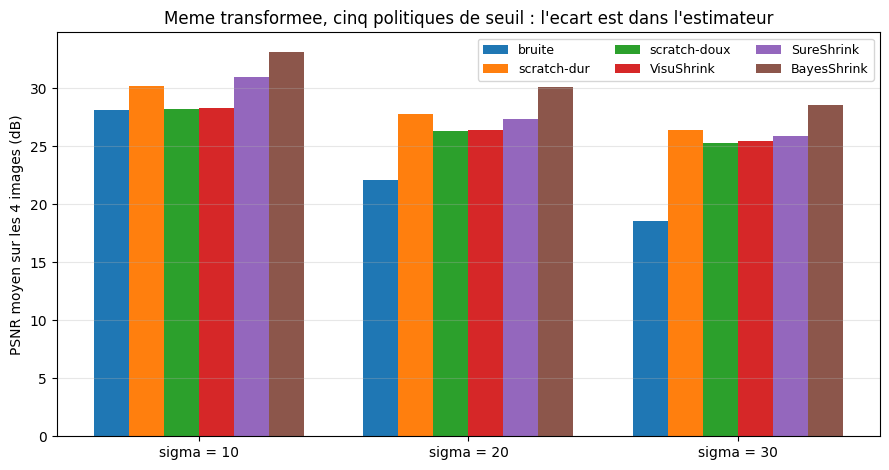

In [9]:
# --- figure : PSNR moyen par methode, a chaque regime de bruit ---
fig, ax = plt.subplots(figsize=(9, 4.8))
larg, dec = 0.13, np.arange(len(SIGMAS))
for i, m in enumerate(METHODES):
    vals = [np.mean([np.mean(RESULTATS[(n, sg, m)]) for n in IMAGES]) for sg in SIGMAS]
    ax.bar(dec + (i - 2.5) * larg, vals, larg, label=m)
ax.set_xticks(dec)
ax.set_xticklabels([f"sigma = {int(s)}" for s in SIGMAS])
ax.set_ylabel("PSNR moyen sur les 4 images (dB)")
ax.set_title("Meme transformee, cinq politiques de seuil : l'ecart est dans l'estimateur")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

### Duel visuel — `camera`, $\sigma = 20$, graine 0

Les PSNR disent *combien* ; les vignettes disent *quoi* : le seuil universel global lisse les textures fines
(les pavés du fond perdent leur trame), BayesShrink les conserve là où la bande porte du signal.
Le recadrage [60:220, 200:420] couvre la façade et les pavés — le terrain où
les deux politiques divergent le plus visiblement.

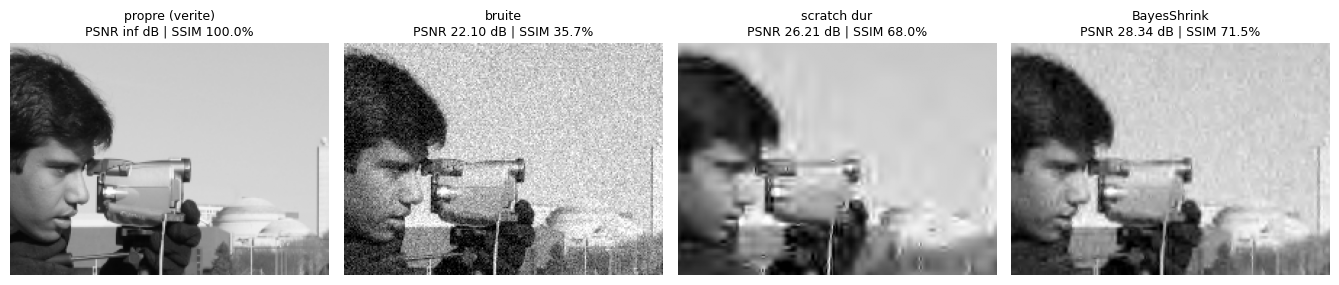

In [10]:
def ssim_db(ref, test):
    return 100.0 * structural_similarity(ref, test, data_range=255.0)

img = IMAGES["camera"]
noisy = img + 20.0 * np.random.default_rng(0).standard_normal(img.shape)
dure, _, _ = denoise_scratch(noisy, soft=False)
bayes = denoise_bayes(noisy, sigma_hat_mad(noisy))
crop = np.s_[60:220, 200:420]

fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.6))
for ax, (titre, v) in zip(axes, [
        ("propre (verite)", img),
        ("bruite", noisy),
        ("scratch dur", dure),
        ("BayesShrink", bayes)]):
    ax.imshow(v[crop], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{titre}\nPSNR {psnr(img, v):.2f} dB | SSIM {ssim_db(img, v):.1f}%", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Lecture.** Les PSNR des vignettes reprennent ceux du premier tour (22,10
pour le bruité, 26,21 pour le dur universel, 28,34 pour BayesShrink — même
image, même σ, même graine), mais la vue ajoute ce que la moyenne ne dit
pas : **où** les décibels se gagnent. Le recadrage couvre les toits et
pavés du fond de `camera` — la texture fine que le seuil universel global
sacrifie en bloc (d'où l'aspect lissé, « dessiné », de la vignette scratch)
et que le seuil adaptatif conserve bande par bande, là où la variance
empirique atteste du signal. Le SSIM, affiché sous chaque vignette, pèse
cette structure bien mieux que le PSNR, qui ne voit qu'une énergie d'erreur
globale : c'est la raison pour laquelle le banc rapporte le PSNR mais le
duel montre les deux.

## 5. Ce que le SOTA achète — et ce qu'il n'achète pas

1. **Le gain vient de l'estimation, pas de la transformée.** Les six lignes du banc partagent la même db4,
   la même pyramide, le même $\hat\sigma$ — et s'étalent pourtant sur plusieurs dB. Entre la baseline
   from scratch (moteur WS-00b, seuil WS-00a) et BayesShrink, il n'y a **aucune différence de moteur** :
   seulement la portée du seuil (global → par sous-bande) et sa loi ($\sqrt{2\ln N}$ → $\hat\sigma^2/\hat\sigma_x$).
2. **L'adaptativité est le levier dominant.** Le seuil universel est calibré pour le pire cas (bruit pur) :
   sur une bande riche en contours, il massacre des coefficients porteurs de signal — d'où le lissage visible
   dans le duel. BayesShrink resserre le seuil exactement là où la variance empirique atteste du signal.
3. **Dur vs doux à seuil universel : l'écart mesuré.** À seuil identique, le doux rétracte *tous* les
   coefficients survivants (biais), le dur les laisse intacts (variance). Sur ce banc, le dur gagne
   systématiquement à régime de seuil universel — mais BayesShrink *doux adaptatif* fait mieux que les deux :
   c'est le couple (loi du seuil, portée adaptative) qui compte, pas le dur ou le doux en soi.
4. **SureShrink, écrit ici, dessine un compromis** : il gagne à faible bruit (31,0 vs 30,2 dB à $\sigma=10$
   sur la moyenne des images) mais cède à fort bruit (25,9 vs 26,4 à $\sigma=30$) — le risque minimisé sans oracle
   récompense les images texturées et se montre prudent quand le bruit domine. Sa validation contre la force
   brute (§3) est la parité mesurée que la série exige de tout code écrit à la main.


### Exercice 1 — BayesShrink à la main

scikit-image le cache derrière un appel ; réécrivez-le. Sur les sous-bandes `pywt.wavedec2`, le seuil de
Chang-Yu-Vetterli d'une bande est $\lambda_B = \hat\sigma^2 / \sqrt{\max(\mathrm{var}(b) - \hat\sigma^2,\; \epsilon)}$.

**Indice** : la variance empirique de la bande se prend sur ses coefficients tels quels (le bruit et le signal
y sont mélangés — c'est justement le point). Comparez votre PSNR à `denoise_bayes` : la parité attendue est de
l'ordre du centième de dB.

In [11]:
def bayes_lambda_main(band, sigma2, eps=1e-12):
    """Seuil BayesShrink d'une sous-bande, a la main (Chang-Yu-Vetterli 2000).

    # Etape 1 : variance empirique des coefficients de la bande
    # Etape 2 : variance du signal estimee par soustraction (plancher eps)
    # Etape 3 : lambda_B = sigma^2 / sqrt(var_signal)
    """
    # TODO etudiant
    return None  # a completer


def denoise_bayes_main(img, sigma):
    """Debruitage BayesShrink complet sur les coefficients pywt, seuillage doux."""
    # TODO etudiant (meme squelette que denoise_sure : wavedec2 -> seuil par bande -> waverec2)
    print("Exercice a completer")
    return None

### Exercice 2 — L'ondelette change-t-elle le verdict ?

Le banc est réglé sur db4. Refaites le tour `camera` / $\sigma=20$ avec `sym8` (8 taps, plus symétrique)
des deux côtés à la fois (moteur from scratch via les constantes publiées *et* lib via `wavelet="sym8"`).

**Indice** : pour le moteur, remplacez la constante `DB4` par les 8 coefficients de `sym8` (publiés dans la
doc pywt) ; la structure de `dwt_axis` ne change pas. Le verdict d'adaptativité (BayesShrink vs universel)
survit-il au changement de base ?

In [12]:
def un_tour_sym8(img, sigma, graine=0):
    """Meme banc que un_tour, mais ondelette sym8 des deux cotes (lib + from scratch).

    # Etape 1 : constantes publiees de sym8 pour le moteur from scratch
    # Etape 2 : denoise_scratch et appels lib avec wavelet='sym8'
    # Etape 3 : retourner le meme dictionnaire de PSNR
    """
    # TODO etudiant
    print("Exercice a completer")
    return None

### Exercice 3 — Un meilleur $\hat\sigma$ sur les images à contours dominants

Le MAD de la §2 lit la bande diagonale la plus fine — hypothèse : elle est quasi pure bruit. Sur `text`
(contours fins partout), l'hypothèse est discutable : le signal fuit dans la bande, $\hat\sigma$ est biaisé
vers le haut, tous les seuils suivent. Mesurez-le.

**Indice** : comparez trois estimateurs — MAD sur HH (le nôtre), MAD médian des trois bandes fines
(cH, cV, cD du niveau 1), et MAD sur la bande **la moins énergétique** du niveau 1. Tracez $\hat\sigma$
estimé contre $\sigma$ vrai pour `text` et `camera` : lequel des deux images trahit le biais ?

In [13]:
def sigma_hat_alternatif(img, strategie="trois-bandes"):
    """Estimation de sigma alternative au MAD-HH de la section 2.

    # Etape 1 : decomposer et isoler les trois bandes du niveau 1
    # Etape 2 : appliquer la strategie ('trois-bandes' ou 'moins-energetique')
    # Etape 3 : retourner le sigma estime
    """
    # TODO etudiant
    print("Exercice a completer")
    return None

## Conclusion

| Politique de seuil | Portée | Ce que le banc en dit |
|---|---|---|
| universel dur/doux (WS-00a/00b, *from scratch*) | global | la baseline honnête : transformée parfaite (parité `allclose`), seuil calibré pire-cas |
| VisuShrink (scikit-image) | global | le même universel en doux, packaging lib (26,8 dB) — colle à la baseline douce from scratch (26,6 dB), rien de plus |
| SureShrink (à la main, SURE validé) | par bande | risque minimisé sans oracle, entre les deux mondes |
| **BayesShrink (scikit-image)** | par bande | **le SOTA du banc** : l'adaptativité par sous-bande paie en dB sur tous les régimes |

**Le concept-phare** : à transformée identique, le débruitage SOTA n'achète pas un meilleur *moteur* —
il achète une meilleure *décision* sur chaque coefficient. Le from scratch des WS-00 n'est pas perdu :
il est la baseline qui rend l'écart mesurable, et le moteur de la parité.

Ponts : le seuillage dur/doux vient de [`WS-00a`](WS-00a-Ondelettes-1D-from-scratch.ipynb), le moteur 2D de
[`WS-00b`](WS-00b-Ondelettes-2D-from-scratch.ipynb). Le reste du bloc B (scattering SOTA `kymatio`, tableau
comparatif final) arrive dans les grains suivants de [#16055](https://github.com/jsboige/CoursIA/issues/16055).

Références : Donoho & Johnstone, *Ideal spatial adaptation by wavelet shrinkage* (Biometrika, 1994) ;
Chang, Yu & Vetterli, *Adaptive wavelet thresholding for image denoising and compression* (IEEE TIP, 2000) ;
documentation `pywt` et `skimage.restoration`.